# **HelmNet: Safety Helmet Image Classification**

## **Business Context**
Workplace safety in construction sites and industrial plants depends on consistent use of personal protective equipment. Manual monitoring is time-consuming and can miss violations. This project develops an image-classification system that identifies whether a worker is wearing a safety helmet.

## **Objective**
Build and compare four deep-learning models:
1. CNN from scratch
2. VGG16 base model
3. VGG16 base + feed-forward neural network (FFNN)
4. VGG16 base + FFNN + data augmentation

The final model is selected using validation performance and evaluated once on the untouched test set.

> **GitHub note:** `images.npy` is intentionally not included in this repository because it is approximately 495 MB. Place your copy at `data/images.npy` before running the notebook. The smaller `labels.csv` file is included under `data/`.


## **Rubric Coverage**
This notebook covers data loading and shape checks, class-level image visualization, class imbalance analysis, stratified train/validation/test splitting, normalization, four required models, model comparison, final test evaluation, and business recommendations.

# **1. Environment Setup**

In [ ]:
# Colab already includes TensorFlow, NumPy, pandas, matplotlib, and scikit-learn.
# Install only small supporting libraries when required. Avoid forcing NumPy upgrades.
%pip install -q seaborn

In [ ]:
import os, random, warnings, gc, time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input

from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)
from sklearn.utils.class_weight import compute_class_weight

warnings.filterwarnings('ignore')
SEED = 812
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

print('TensorFlow:', tf.__version__)
print('GPU devices:', tf.config.list_physical_devices('GPU'))

TensorFlow: 2.20.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


# **2. Load Data from Google Drive**

In [ ]:
from pathlib import Path

# Portable project paths.
# Expected repository structure:
# HelmNet/
# ├── HelmNet_Helmet_Detection.ipynb
# ├── data/
# │   ├── images.npy      # not included in GitHub package
# │   └── labels.csv
# └── artifacts/

PROJECT_DIR = Path(".")
DATA_DIR = PROJECT_DIR / "data"
ARTIFACT_DIR = PROJECT_DIR / "artifacts"

# Colab fallback: upload/copy files into /content/data/
if not DATA_DIR.exists() and Path("/content/data").exists():
    DATA_DIR = Path("/content/data")

IMAGES_PATH = DATA_DIR / "images.npy"
LABELS_PATH = DATA_DIR / "labels.csv"

ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

assert IMAGES_PATH.exists(), (
    f"File not found: {IMAGES_PATH}\n"
    "Place images.npy inside the data/ folder. See data/README.md."
)
assert LABELS_PATH.exists(), f"File not found: {LABELS_PATH}"

print("Images file:", IMAGES_PATH)
print("Labels file:", LABELS_PATH)


## **2.1 Data Overview — Load Dataset and Check Shape**

In [ ]:
# mmap_mode='r' avoids immediately copying the entire 450 MB array into RAM.
images_raw = np.load(IMAGES_PATH, mmap_mode='r')
labels_df = pd.read_csv(LABELS_PATH)

assert 'label' in labels_df.columns, "labels.csv must contain a column named 'label'."
y = labels_df['label'].astype('int32').to_numpy()

print('Raw image array shape :', images_raw.shape)
print('Labels shape          :', y.shape)
print('Image dtype           :', images_raw.dtype)
print('Unique labels         :', np.unique(y))
print('Approx. array size GB :', round(images_raw.nbytes / (1024**3), 3))

assert len(images_raw) == len(y), 'Number of images and labels must match.'
assert len(np.unique(y)) == 2, 'This notebook expects binary labels.'

# Normalize the image tensor layout to (N, H, W, C).
# Supports (N,H,W), (N,H,W,1), (N,H,W,3), (N,H,W,4), or channel-first (N,C,H,W).
if images_raw.ndim == 3:
    X = np.expand_dims(images_raw, axis=-1)
elif images_raw.ndim == 4 and images_raw.shape[-1] in (1, 3, 4):
    X = images_raw
elif images_raw.ndim == 4 and images_raw.shape[1] in (1, 3, 4):
    X = np.transpose(images_raw, (0, 2, 3, 1))
else:
    raise ValueError(f'Unsupported image shape: {images_raw.shape}')

# Convert grayscale to RGB and discard alpha if present.
if X.shape[-1] == 1:
    X = np.repeat(X, 3, axis=-1)
elif X.shape[-1] == 4:
    X = X[..., :3]

print('Model-ready image shape:', X.shape)
print('Pixel range:', float(np.min(X[:50])), 'to', float(np.max(X[:50])))

Raw image array shape : (4125, 200, 200, 3)
Labels shape          : (4125,)
Image dtype           : uint8
Unique labels         : [0 1]
Approx. array size GB : 0.461
Model-ready image shape: (4125, 200, 200, 3)
Pixel range: 0.0 to 255.0


### **Data Overview Observations**
- The number of image records must equal the number of labels.
- The model-ready tensor is standardized to RGB format `(samples, height, width, 3)`.
- Memory mapping is used because the image file is large; this makes loading more memory-efficient in Colab.

# **3. Exploratory Data Analysis**

## **3.1 Plot Random Images from Each Class and Print Labels**

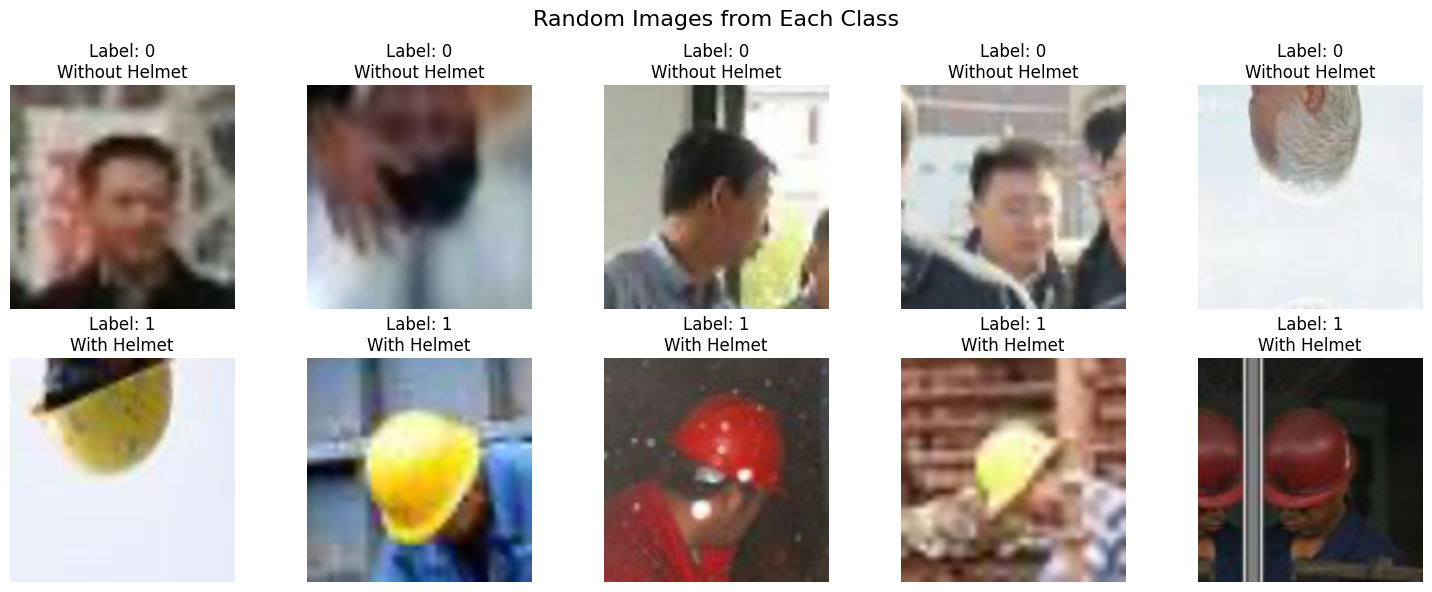

In [ ]:
CLASS_NAMES = {0: 'Without Helmet', 1: 'With Helmet'}
# labels.csv contains 964 class-0 and 3161 class-1 records, matching the project description.

def show_random_images_by_class(X, y, class_names, n_per_class=5, seed=SEED):
    rng = np.random.default_rng(seed)
    classes = np.unique(y)
    fig, axes = plt.subplots(len(classes), n_per_class, figsize=(15, 6))
    axes = np.atleast_2d(axes)
    for row, cls in enumerate(classes):
        indices = np.where(y == cls)[0]
        chosen = rng.choice(indices, size=min(n_per_class, len(indices)), replace=False)
        for col, idx in enumerate(chosen):
            img = np.asarray(X[idx])
            if img.dtype != np.uint8:
                display_img = np.clip(img, 0, 255).astype(np.uint8) if img.max() > 1 else np.clip(img, 0, 1)
            else:
                display_img = img
            axes[row, col].imshow(display_img)
            axes[row, col].set_title(f'Label: {y[idx]}\n{class_names.get(int(y[idx]), str(y[idx]))}')
            axes[row, col].axis('off')
    plt.suptitle('Random Images from Each Class', fontsize=16)
    plt.tight_layout()
    plt.show()

show_random_images_by_class(X, y, CLASS_NAMES, n_per_class=5)

## **3.2 Check for Class Imbalance**

,Class Name,Count,Percentage
0,Without Helmet,964,23.37
1,With Helmet,3161,76.63


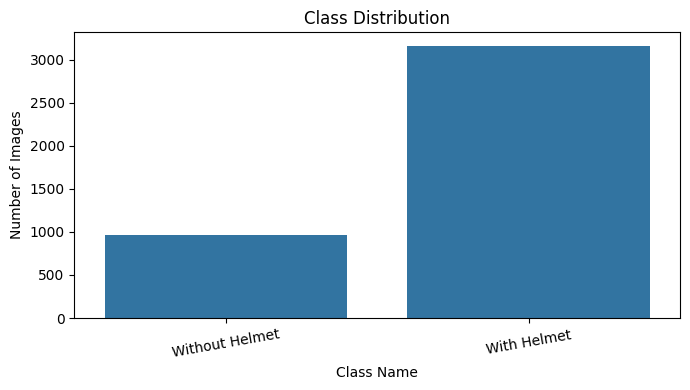

Imbalance ratio (majority/minority): 3.28:1
Observation: The dataset is imbalanced. Stratification and class weights will be used.


In [ ]:
class_counts = pd.Series(y).value_counts().sort_index()
class_percent = (class_counts / len(y) * 100).round(2)
class_summary = pd.DataFrame({
    'Class Name': [CLASS_NAMES.get(int(i), str(i)) for i in class_counts.index],
    'Count': class_counts.values,
    'Percentage': class_percent.values
}, index=class_counts.index)
display(class_summary)

plt.figure(figsize=(7, 4))
sns.barplot(data=class_summary.reset_index(), x='Class Name', y='Count')
plt.title('Class Distribution')
plt.ylabel('Number of Images')
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()

imbalance_ratio = class_counts.max() / class_counts.min()
print(f'Imbalance ratio (majority/minority): {imbalance_ratio:.2f}:1')
if imbalance_ratio >= 1.5:
    print('Observation: The dataset is imbalanced. Stratification and class weights will be used.')
else:
    print('Observation: The class distribution is reasonably balanced.')

## **3.3 Key EDA Observations**
- Visual inspection confirms whether label encoding matches the stated business classes.
- Differences in lighting, scale, pose, background, and helmet visibility can make classification challenging.
- Class imbalance can bias accuracy toward the majority class, so F1-score and recall are evaluated in addition to accuracy.
- Stratified splitting preserves the class proportions in train, validation, and test subsets.
- Data augmentation is expected to improve robustness to real-world variation.

# **4. Data Pre-processing**

## **4.1 Stratified Train, Validation, and Test Split**

In [ ]:
indices = np.arange(len(y))

# 70% train, 15% validation, 15% test
train_idx, temp_idx = train_test_split(
    indices, test_size=0.30, stratify=y, random_state=SEED
)
val_idx, test_idx = train_test_split(
    temp_idx, test_size=0.50, stratify=y[temp_idx], random_state=SEED
)

X_train, y_train = np.asarray(X[train_idx]), y[train_idx]
X_val, y_val = np.asarray(X[val_idx]), y[val_idx]
X_test, y_test = np.asarray(X[test_idx]), y[test_idx]

print('Train:', X_train.shape, y_train.shape)
print('Validation:', X_val.shape, y_val.shape)
print('Test:', X_test.shape, y_test.shape)

for name, values in [('Train', y_train), ('Validation', y_val), ('Test', y_test)]:
    print(f'{name} class proportions:', pd.Series(values).value_counts(normalize=True).sort_index().round(3).to_dict())

Train: (2887, 200, 200, 3) (2887,)
Validation: (619, 200, 200, 3) (619,)
Test: (619, 200, 200, 3) (619,)
Train class proportions: {0: 0.234, 1: 0.766}
Validation class proportions: {0: 0.234, 1: 0.766}
Test class proportions: {0: 0.233, 1: 0.767}


## **4.2 Normalization and Input Pipelines**

In [ ]:
# Convert only the split arrays to float32. Pixel normalization for the scratch CNN
# is performed inside the model using Rescaling, preventing unnecessary duplicate arrays.
X_train = X_train.astype('float32')
X_val = X_val.astype('float32')
X_test = X_test.astype('float32')

# Automatically determine whether pixels are [0,1] or [0,255].
PIXEL_SCALE = 255.0 if X_train.max() > 1.5 else 1.0
print('Normalization divisor:', PIXEL_SCALE)
print('Normalized sample range:', X_train[:10].min()/PIXEL_SCALE, 'to', X_train[:10].max()/PIXEL_SCALE)

BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

def make_dataset(X_data, y_data, training=False):
    ds = tf.data.Dataset.from_tensor_slices((X_data, y_data))
    if training:
        ds = ds.shuffle(len(y_data), seed=SEED, reshuffle_each_iteration=True)
    return ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

train_ds = make_dataset(X_train, y_train, training=True)
val_ds = make_dataset(X_val, y_val)
test_ds = make_dataset(X_test, y_test)

classes = np.unique(y_train)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
CLASS_WEIGHT = {int(c): float(w) for c, w in zip(classes, weights)}
print('Class weights:', CLASS_WEIGHT)

Normalization divisor: 255.0
Normalized sample range: 0.0 to 1.0
Class weights: {0: 2.1385185185185187, 1: 0.6525768535262206}


### **Pre-processing Observation**
Normalization places pixel values on a consistent scale. The test set remains untouched during model selection and is used only once after choosing the best validation model.

# **5. Model Building and Evaluation Framework**

## **Evaluation Criterion**
Because this is a safety application and the classes may be imbalanced, models are compared primarily using **validation F1-score**, supported by recall and accuracy. F1-score balances precision and recall, while recall is important for reducing missed helmet violations.

In [ ]:
INPUT_SHAPE = X_train.shape[1:]
EPOCHS = 15
LEARNING_RATE = 1e-3

def get_callbacks(model_name):
    return [
        callbacks.EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True, verbose=1),
        callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=2, min_lr=1e-6, verbose=1),
        callbacks.ModelCheckpoint(
            filepath=str(PROJECT_DIR / f'{model_name}.keras'),
            monitor='val_loss', save_best_only=True, verbose=0
        )
    ]

def plot_history(history, title):
    hist = pd.DataFrame(history.history)
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    axes[0].plot(hist['loss'], label='Train')
    axes[0].plot(hist['val_loss'], label='Validation')
    axes[0].set_title(f'{title} - Loss')
    axes[0].set_xlabel('Epoch'); axes[0].legend()
    axes[1].plot(hist['accuracy'], label='Train')
    axes[1].plot(hist['val_accuracy'], label='Validation')
    axes[1].set_title(f'{title} - Accuracy')
    axes[1].set_xlabel('Epoch'); axes[1].legend()
    plt.tight_layout(); plt.show()

def evaluate_model(model, X_data, y_data, model_name, threshold=0.5, show=True):
    probs = model.predict(X_data, batch_size=BATCH_SIZE, verbose=0).reshape(-1)
    preds = (probs >= threshold).astype(int)
    result = {
        'Model': model_name,
        'Accuracy': accuracy_score(y_data, preds),
        'Precision': precision_score(y_data, preds, zero_division=0),
        'Recall (Macro)': recall_score(y_data, preds, average='macro', zero_division=0),
        'Violation Recall': recall_score(y_data, preds, pos_label=0, zero_division=0),
        'F1 Score': f1_score(y_data, preds, average='macro', zero_division=0)
    }
    if show:
        print(pd.DataFrame([result]).round(4).to_string(index=False))
        print('\nClassification Report:\n', classification_report(y_data, preds, target_names=[CLASS_NAMES[0], CLASS_NAMES[1]], zero_division=0))
        cm = confusion_matrix(y_data, preds)
        plt.figure(figsize=(5, 4))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=[CLASS_NAMES[0], CLASS_NAMES[1]],
                    yticklabels=[CLASS_NAMES[0], CLASS_NAMES[1]])
        plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.title(f'{model_name} Confusion Matrix')
        plt.tight_layout(); plt.show()
    return result

def show_predictions(model, X_data, y_data, title, n=10):
    rng = np.random.default_rng(SEED)
    idxs = rng.choice(len(y_data), size=min(n, len(y_data)), replace=False)
    probs = model.predict(X_data[idxs], verbose=0).reshape(-1)
    preds = (probs >= 0.5).astype(int)
    fig, axes = plt.subplots(2, 5, figsize=(15, 6))
    axes = axes.flatten()
    for ax, idx, pred, prob in zip(axes, idxs, preds, probs):
        img = X_data[idx] / PIXEL_SCALE
        ax.imshow(np.clip(img, 0, 1))
        ok = pred == y_data[idx]
        ax.set_title(f'True: {CLASS_NAMES[int(y_data[idx])]}\nPred: {CLASS_NAMES[int(pred)]} ({prob:.2f})\n{"Correct" if ok else "Incorrect"}')
        ax.axis('off')
    plt.suptitle(title, fontsize=15)
    plt.tight_layout(); plt.show()

validation_results = []
models_trained = {}

# **6. Model 1 — CNN from Scratch**

In [ ]:
tf.keras.backend.clear_session()

cnn_model = models.Sequential([
    layers.Input(shape=INPUT_SHAPE),
    layers.Rescaling(1.0 / PIXEL_SCALE),
    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    layers.Conv2D(128, 3, padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    layers.Conv2D(256, 3, padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(1, activation='sigmoid')
], name='CNN_From_Scratch')

cnn_model.compile(optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
                  loss='binary_crossentropy', metrics=['accuracy'])
cnn_model.summary()
print(f'Configuration: Adam lr={LEARNING_RATE}, loss=binary_crossentropy, epochs={EPOCHS}, batch={BATCH_SIZE}')

Model: "CNN_From_Scratch"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 200, 200, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 200, 200, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 200, 200, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 100, 100, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 100, 100, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 100, 100, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 50, 50, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 50, 50, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 50, 50, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 25, 25, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 25, 25, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 25, 25, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 423,361 (1.61 MB)

 Trainable params: 422,401 (1.61 MB)

 Non-trainable params: 960 (3.75 KB)

Configuration: Adam lr=0.001, loss=binary_crossentropy, epochs=15, batch=32


Epoch 1/15
91/91 ━━━━━━━━━━━━━━━━━━━━ 27s 166ms/step - accuracy: 0.6747 - loss: 0.6024 - val_accuracy: 0.2342 - val_loss: 1.1503 - learning_rate: 0.0010
Epoch 2/15
91/91 ━━━━━━━━━━━━━━━━━━━━ 6s 61ms/step - accuracy: 0.7506 - loss: 0.5096 - val_accuracy: 0.2342 - val_loss: 1.6086 - learning_rate: 0.0010
Epoch 3/15
91/91 ━━━━━━━━━━━━━━━━━━━━ 6s 65ms/step - accuracy: 0.7683 - loss: 0.4865 - val_accuracy: 0.5153 - val_loss: 0.9452 - learning_rate: 0.0010
Epoch 4/15
91/91 ━━━━━━━━━━━━━━━━━━━━ 6s 65ms/step - accuracy: 0.7731 - loss: 0.4705 - val_accuracy: 0.6979 - val_loss: 0.6356 - learning_rate: 0.0010
Epoch 5/15
91/91 ━━━━━━━━━━━━━━━━━━━━ 6s 63ms/step - accuracy: 0.7891 - loss: 0.4500 - val_accuracy: 0.4620 - val_loss: 1.1190 - learning_rate: 0.0010
Epoch 6/15
91/91 ━━━━━━━━━━━━━━━━━━━━ 6s 63ms/step - accuracy: 0.8188 - loss: 0.4116 - val_accuracy: 0.6963 - val_loss: 0.6056 - learning_rate: 0.0010
Epoch 7/15
91/91 ━━━━━━━━━━━━━━━━━━━━ 6s 63ms/step - accuracy: 0.8164 - loss: 0.4071 - val_a

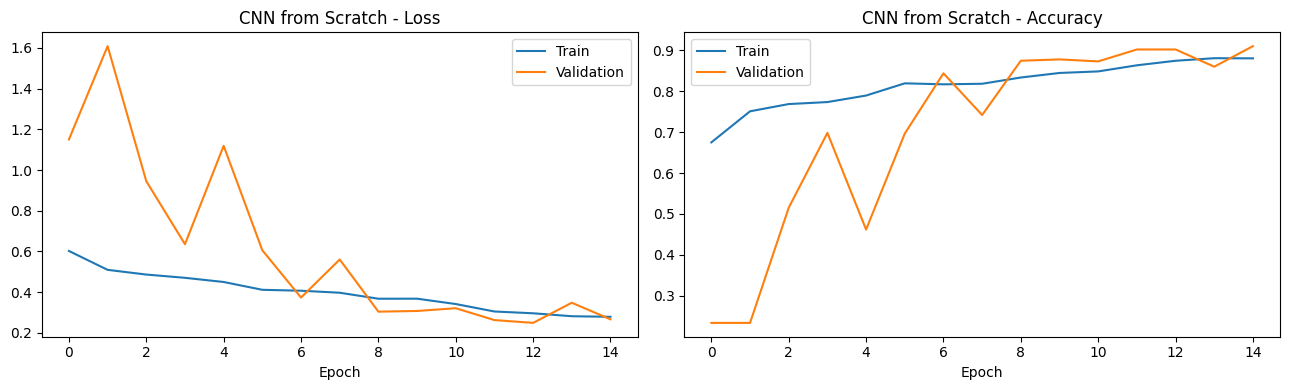

           Model  Accuracy  Precision  Recall (Macro)  Violation Recall  F1 Score
CNN from Scratch    0.9015      0.946          0.8758            0.8276    0.8661

Classification Report:
                 precision    recall  f1-score   support

Without Helmet       0.77      0.83      0.80       145
   With Helmet       0.95      0.92      0.93       474

      accuracy                           0.90       619
     macro avg       0.86      0.88      0.87       619
  weighted avg       0.90      0.90      0.90       619



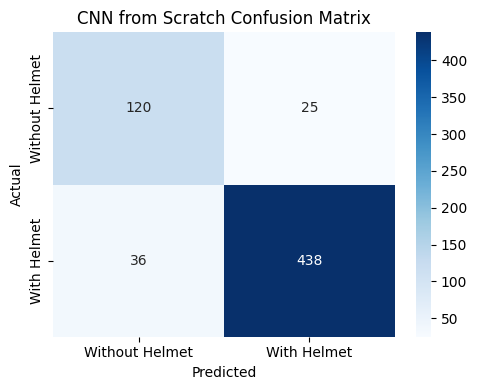

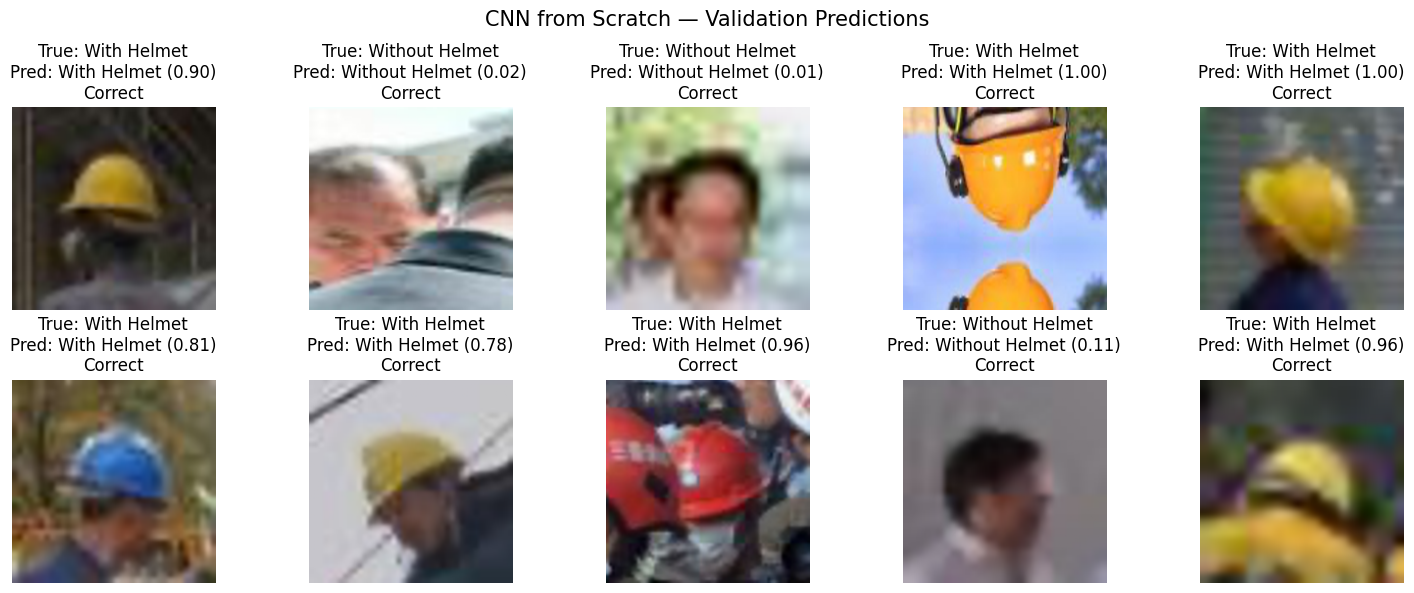

In [ ]:
start = time.time()
history_cnn = cnn_model.fit(
    train_ds, validation_data=val_ds, epochs=EPOCHS,
    class_weight=CLASS_WEIGHT, callbacks=get_callbacks('cnn_from_scratch'), verbose=1
)
print(f'Training time: {(time.time()-start)/60:.1f} minutes')
plot_history(history_cnn, 'CNN from Scratch')
cnn_val = evaluate_model(cnn_model, X_val, y_val, 'CNN from Scratch')
validation_results.append(cnn_val)
models_trained['CNN from Scratch'] = cnn_model
show_predictions(cnn_model, X_val, y_val, 'CNN from Scratch — Validation Predictions')

### **Model 1 Performance Comments**
- Compare training and validation curves to detect overfitting. A widening gap suggests that the scratch CNN is memorizing the training data.
- The confusion matrix reveals which safety class is harder to classify.
- This model provides a baseline for measuring the value of pretrained VGG16 features.

# **7. Model 2 — Transfer Learning with VGG16 Base**

In [ ]:
def vgg_preprocessing_block():
    return keras.Sequential([
        layers.Resizing(224, 224),
        layers.Rescaling(255.0 / PIXEL_SCALE),
        layers.Lambda(preprocess_input)
    ], name='vgg_preprocessing')

tf.keras.backend.clear_session()
vgg_base_1 = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
vgg_base_1.trainable = False

inputs = layers.Input(shape=INPUT_SHAPE)
x = vgg_preprocessing_block()(inputs)
x = vgg_base_1(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
outputs = layers.Dense(1, activation='sigmoid')(x)
vgg_base_model = keras.Model(inputs, outputs, name='VGG16_Base')

vgg_base_model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3),
                       loss='binary_crossentropy', metrics=['accuracy'])
vgg_base_model.summary()
print(f'Configuration: frozen VGG16, Adam lr=0.001, epochs={EPOCHS}, batch={BATCH_SIZE}')

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


Model: "VGG16_Base"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 200, 200, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg_preprocessing (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,715,201 (56.13 MB)

 Trainable params: 513 (2.00 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

Configuration: frozen VGG16, Adam lr=0.001, epochs=15, batch=32


In [ ]:
start = time.time()
history_vgg_base = vgg_base_model.fit(
    train_ds, validation_data=val_ds, epochs=EPOCHS,
    class_weight=CLASS_WEIGHT, callbacks=get_callbacks('vgg16_base'), verbose=1
)
print(f'Training time: {(time.time()-start)/60:.1f} minutes')
plot_history(history_vgg_base, 'VGG16 Base')
vgg_base_val = evaluate_model(vgg_base_model, X_val, y_val, 'VGG16 Base')
validation_results.append(vgg_base_val)
models_trained['VGG16 Base'] = vgg_base_model
show_predictions(vgg_base_model, X_val, y_val, 'VGG16 Base — Validation Predictions')

### **Model 2 Performance Comments**
The frozen VGG16 convolutional base contributes pretrained visual features learned from ImageNet. It should train faster than full fine-tuning and can outperform a scratch CNN when the project dataset is relatively small.

# **8. Model 3 — VGG16 Base + FFNN**

In [ ]:
tf.keras.backend.clear_session()
vgg_base_2 = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
vgg_base_2.trainable = False

inputs = layers.Input(shape=INPUT_SHAPE)
x = vgg_preprocessing_block()(inputs)
x = vgg_base_2(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.5)(x)
x = layers.Dense(64, activation='relu')(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(1, activation='sigmoid')(x)
vgg_ffnn_model = keras.Model(inputs, outputs, name='VGG16_Base_FFNN')

vgg_ffnn_model.compile(optimizer=keras.optimizers.Adam(learning_rate=5e-4),
                       loss='binary_crossentropy', metrics=['accuracy'])
vgg_ffnn_model.summary()
print(f'Configuration: frozen VGG16 + FFNN, Adam lr=0.0005, epochs={EPOCHS}, batch={BATCH_SIZE}')

Model: "VGG16_Base_FFNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 200, 200, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg_preprocessing (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,863,553 (56.70 MB)

 Trainable params: 148,353 (579.50 KB)

 Non-trainable params: 14,715,200 (56.13 MB)

Configuration: frozen VGG16 + FFNN, Adam lr=0.0005, epochs=15, batch=32


Epoch 1/15
91/91 ━━━━━━━━━━━━━━━━━━━━ 50s 351ms/step - accuracy: 0.8043 - loss: 0.4562 - val_accuracy: 0.9305 - val_loss: 0.1682 - learning_rate: 5.0000e-04
Epoch 2/15
91/91 ━━━━━━━━━━━━━━━━━━━━ 19s 213ms/step - accuracy: 0.8687 - loss: 0.2683 - val_accuracy: 0.9176 - val_loss: 0.1765 - learning_rate: 5.0000e-04
Epoch 3/15
91/91 ━━━━━━━━━━━━━━━━━━━━ 20s 224ms/step - accuracy: 0.9002 - loss: 0.2122 - val_accuracy: 0.9370 - val_loss: 0.1470 - learning_rate: 5.0000e-04
Epoch 4/15
91/91 ━━━━━━━━━━━━━━━━━━━━ 20s 222ms/step - accuracy: 0.9203 - loss: 0.1960 - val_accuracy: 0.9257 - val_loss: 0.1835 - learning_rate: 5.0000e-04
Epoch 5/15
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step - accuracy: 0.9204 - loss: 0.1707
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0001500000071246177.
91/91 ━━━━━━━━━━━━━━━━━━━━ 20s 224ms/step - accuracy: 0.9269 - loss: 0.1636 - val_accuracy: 0.9208 - val_loss: 0.1727 - learning_rate: 5.0000e-04
Epoch 6/15
91/91 ━━━━━━━━━━━━━━━━━━━━ 21s 227ms/step - accuracy:

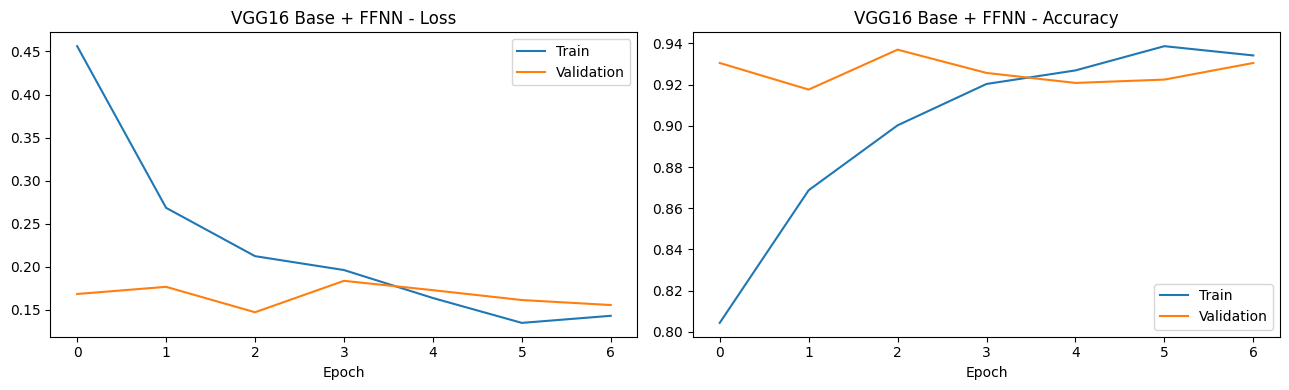

            Model  Accuracy  Precision  Recall (Macro)  Violation Recall  F1 Score
VGG16 Base + FFNN     0.937      0.978          0.9349             0.931    0.9159

Classification Report:
                 precision    recall  f1-score   support

Without Helmet       0.82      0.93      0.87       145
   With Helmet       0.98      0.94      0.96       474

      accuracy                           0.94       619
     macro avg       0.90      0.93      0.92       619
  weighted avg       0.94      0.94      0.94       619



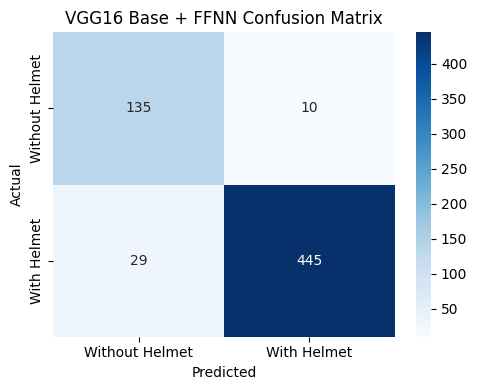

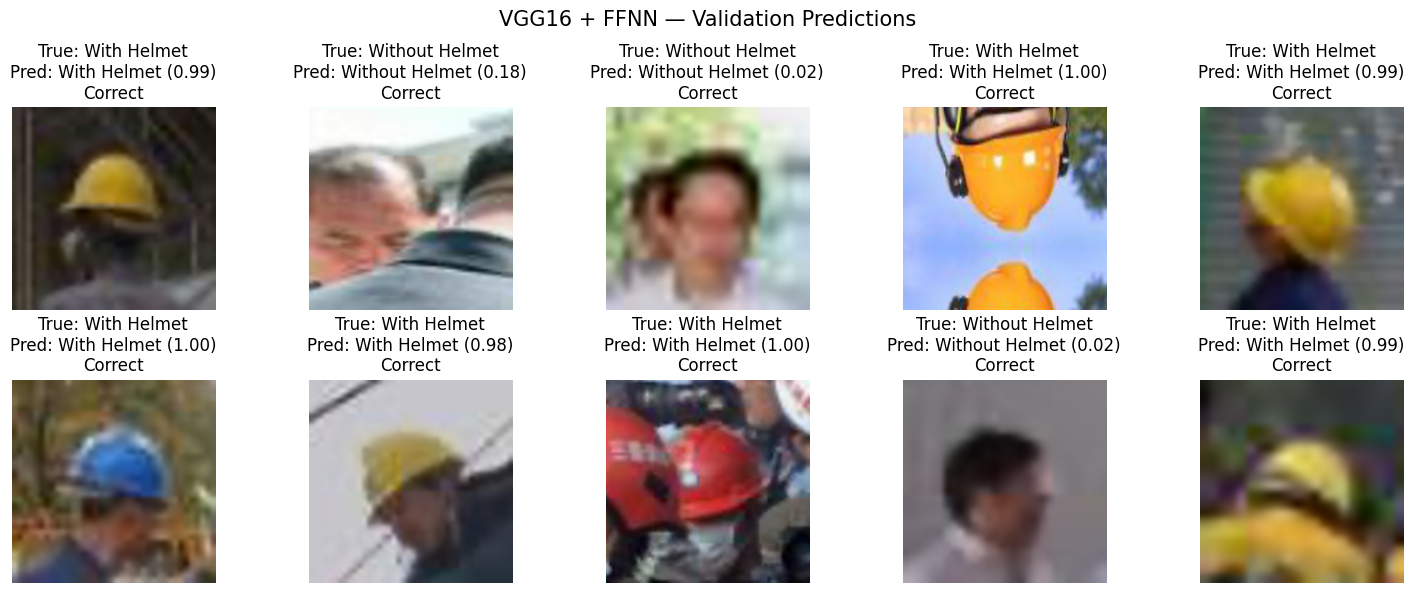

In [ ]:
start = time.time()
history_vgg_ffnn = vgg_ffnn_model.fit(
    train_ds, validation_data=val_ds, epochs=EPOCHS,
    class_weight=CLASS_WEIGHT, callbacks=get_callbacks('vgg16_ffnn'), verbose=1
)
print(f'Training time: {(time.time()-start)/60:.1f} minutes')
plot_history(history_vgg_ffnn, 'VGG16 Base + FFNN')
vgg_ffnn_val = evaluate_model(vgg_ffnn_model, X_val, y_val, 'VGG16 Base + FFNN')
validation_results.append(vgg_ffnn_val)
models_trained['VGG16 Base + FFNN'] = vgg_ffnn_model
show_predictions(vgg_ffnn_model, X_val, y_val, 'VGG16 + FFNN — Validation Predictions')

### **Model 3 Performance Comments**
The additional FFNN layers learn task-specific combinations of VGG16 features. Dropout and batch normalization help control overfitting. Improvement over Model 2 indicates that the custom classification head adds useful capacity.

# **9. Model 4 — VGG16 Base + FFNN + Data Augmentation**

In [ ]:
data_augmentation = keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.12),
    layers.RandomTranslation(0.08, 0.08),
    layers.RandomContrast(0.15)
], name='data_augmentation')

tf.keras.backend.clear_session()
vgg_base_3 = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
vgg_base_3.trainable = False

inputs = layers.Input(shape=INPUT_SHAPE)
x = data_augmentation(inputs)
x = vgg_preprocessing_block()(x)
x = vgg_base_3(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.5)(x)
x = layers.Dense(64, activation='relu')(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(1, activation='sigmoid')(x)
vgg_aug_model = keras.Model(inputs, outputs, name='VGG16_FFNN_Augmentation')

vgg_aug_model.compile(optimizer=keras.optimizers.Adam(learning_rate=5e-4),
                      loss='binary_crossentropy', metrics=['accuracy'])
vgg_aug_model.summary()
print(f'Configuration: frozen VGG16 + FFNN + augmentation, Adam lr=0.0005, epochs={EPOCHS}, batch={BATCH_SIZE}')

Model: "VGG16_FFNN_Augmentation"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 200, 200, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 200, 200, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg_preprocessing (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,863,553 (56.70 MB)

 Trainable params: 148,353 (579.50 KB)

 Non-trainable params: 14,715,200 (56.13 MB)

Configuration: frozen VGG16 + FFNN + augmentation, Adam lr=0.0005, epochs=15, batch=32


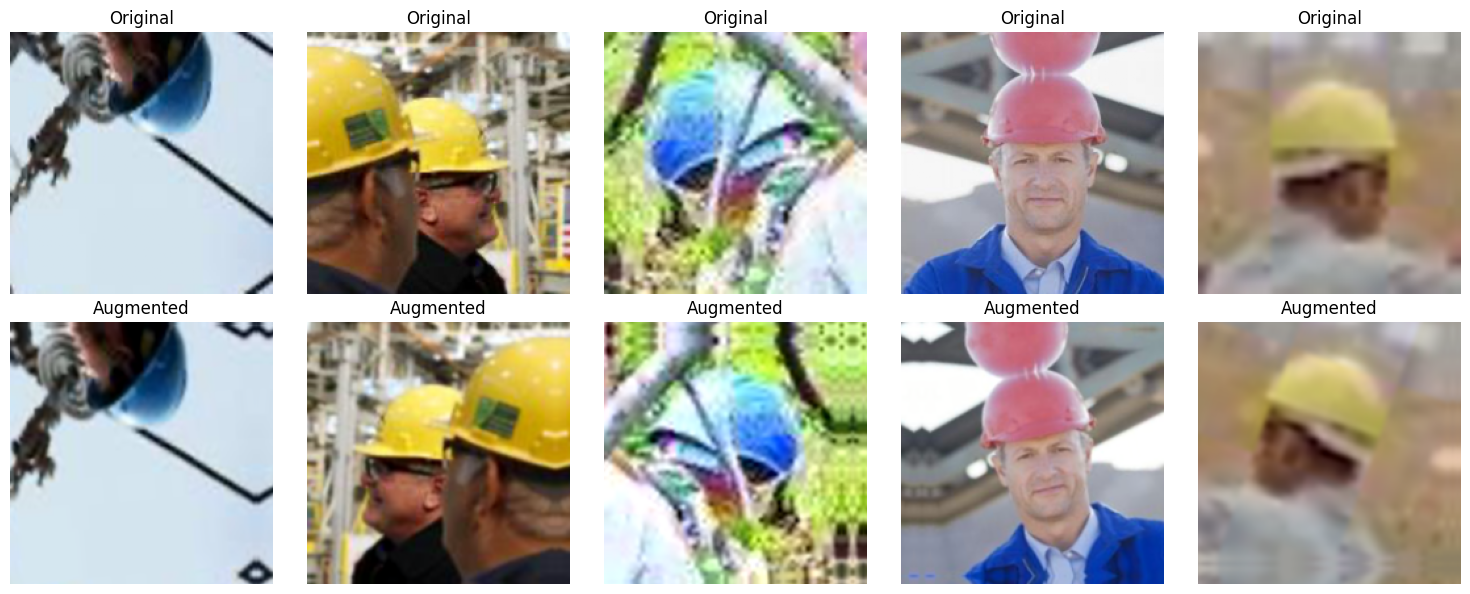

Epoch 1/15
91/91 ━━━━━━━━━━━━━━━━━━━━ 30s 217ms/step - accuracy: 0.7281 - loss: 0.5086 - val_accuracy: 0.9289 - val_loss: 0.1758 - learning_rate: 5.0000e-04
Epoch 2/15
91/91 ━━━━━━━━━━━━━━━━━━━━ 17s 185ms/step - accuracy: 0.8611 - loss: 0.2899 - val_accuracy: 0.9192 - val_loss: 0.1825 - learning_rate: 5.0000e-04
Epoch 3/15
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step - accuracy: 0.8829 - loss: 0.2719
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0001500000071246177.
91/91 ━━━━━━━━━━━━━━━━━━━━ 17s 185ms/step - accuracy: 0.8836 - loss: 0.2596 - val_accuracy: 0.9063 - val_loss: 0.2122 - learning_rate: 5.0000e-04
Epoch 4/15
91/91 ━━━━━━━━━━━━━━━━━━━━ 17s 187ms/step - accuracy: 0.8989 - loss: 0.2429 - val_accuracy: 0.9225 - val_loss: 0.1766 - learning_rate: 1.5000e-04
Epoch 5/15
91/91 ━━━━━━━━━━━━━━━━━━━━ 18s 194ms/step - accuracy: 0.9023 - loss: 0.2115 - val_accuracy: 0.9305 - val_loss: 0.1553 - learning_rate: 1.5000e-04
Epoch 6/15
91/91 ━━━━━━━━━━━━━━━━━━━━ 17s 191ms/step - accuracy:

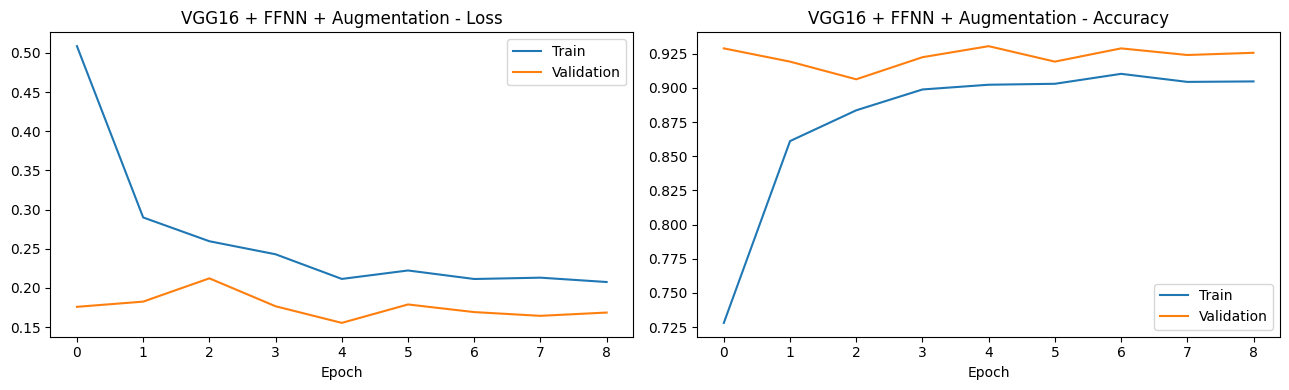

                      Model  Accuracy  Precision  Recall (Macro)  Violation Recall  F1 Score
VGG16 + FFNN + Augmentation    0.9305     0.9716          0.9235            0.9103    0.9069

Classification Report:
                 precision    recall  f1-score   support

Without Helmet       0.81      0.91      0.86       145
   With Helmet       0.97      0.94      0.95       474

      accuracy                           0.93       619
     macro avg       0.89      0.92      0.91       619
  weighted avg       0.93      0.93      0.93       619



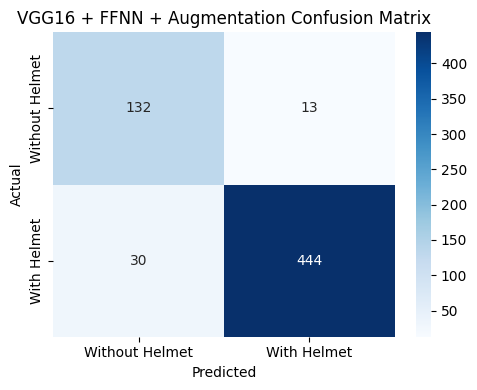

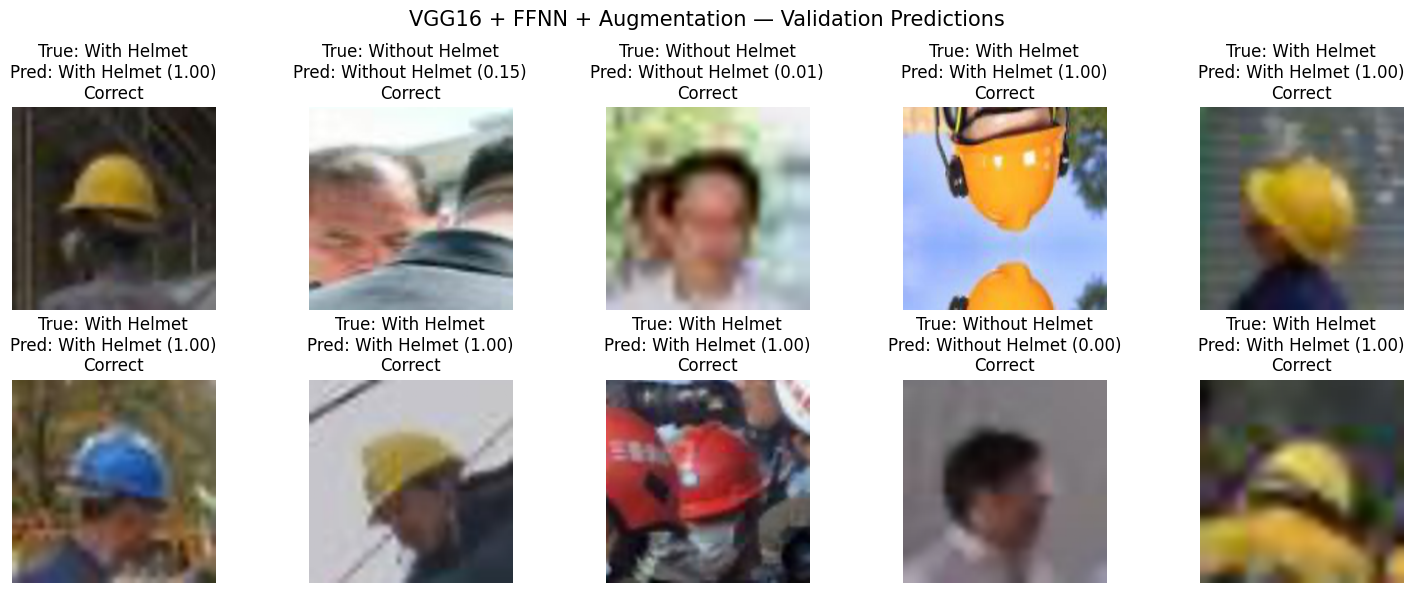

In [ ]:
# Visualize augmented samples before training.
sample_batch = X_train[:5]
augmented = data_augmentation(sample_batch, training=True).numpy()
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i in range(5):
    axes[0, i].imshow(np.clip(sample_batch[i] / PIXEL_SCALE, 0, 1)); axes[0, i].set_title('Original'); axes[0, i].axis('off')
    axes[1, i].imshow(np.clip(augmented[i] / PIXEL_SCALE, 0, 1)); axes[1, i].set_title('Augmented'); axes[1, i].axis('off')
plt.tight_layout(); plt.show()

start = time.time()
history_vgg_aug = vgg_aug_model.fit(
    train_ds, validation_data=val_ds, epochs=EPOCHS,
    class_weight=CLASS_WEIGHT, callbacks=get_callbacks('vgg16_ffnn_aug'), verbose=1
)
print(f'Training time: {(time.time()-start)/60:.1f} minutes')
plot_history(history_vgg_aug, 'VGG16 + FFNN + Augmentation')
vgg_aug_val = evaluate_model(vgg_aug_model, X_val, y_val, 'VGG16 + FFNN + Augmentation')
validation_results.append(vgg_aug_val)
models_trained['VGG16 + FFNN + Augmentation'] = vgg_aug_model
show_predictions(vgg_aug_model, X_val, y_val, 'VGG16 + FFNN + Augmentation — Validation Predictions')

### **Model 4 Performance Comments**
Data augmentation exposes the classifier to realistic transformations and acts as regularization. The strongest evidence of benefit is improved validation F1/recall and a smaller train–validation gap compared with Model 3.

# **10. Model Performance Comparison and Final Model Selection**

,Accuracy,Precision,Recall (Macro),Violation Recall,F1 Score
Model,,,,,
VGG16 Base + FFNN,0.9370,0.9780,0.9349,0.9310,0.9159
VGG16 + FFNN + Augmentation,0.9305,0.9716,0.9235,0.9103,0.9069
CNN from Scratch,0.9015,0.9460,0.8758,0.8276,0.8661


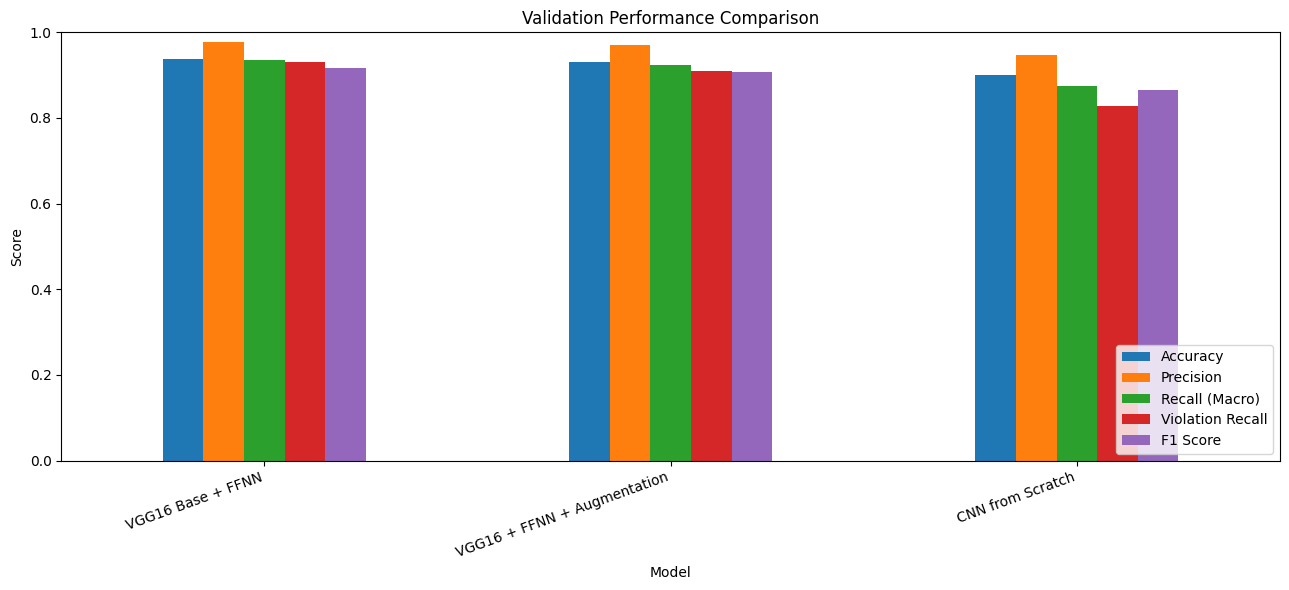

Selected final model: VGG16 Base + FFNN
Reason: It achieved the highest validation F1-score (0.9159), with violation recall of 0.9310 and accuracy of 0.9370.


In [ ]:
comparison_df = pd.DataFrame(validation_results).set_index('Model').sort_values('F1 Score', ascending=False)
display(comparison_df.style.format('{:.4f}').highlight_max(axis=0))

comparison_df[['Accuracy', 'Precision', 'Recall (Macro)', 'Violation Recall', 'F1 Score']].plot(kind='bar', figsize=(13, 6))
plt.ylim(0, 1)
plt.title('Validation Performance Comparison')
plt.ylabel('Score')
plt.xticks(rotation=20, ha='right')
plt.legend(loc='lower right')
plt.tight_layout(); plt.show()

BEST_MODEL_NAME = comparison_df.index[0]
best_model = models_trained[BEST_MODEL_NAME]
print('Selected final model:', BEST_MODEL_NAME)
print(f"Reason: It achieved the highest validation F1-score ({comparison_df.iloc[0]['F1 Score']:.4f}), "
      f"with violation recall of {comparison_df.iloc[0]['Violation Recall']:.4f} and accuracy of {comparison_df.iloc[0]['Accuracy']:.4f}.")

## **Final Model Selection Reasoning**
The final model is chosen only from validation results. F1-score is the primary criterion because it balances false alarms and missed violations under class imbalance. Recall and accuracy are used as supporting measures. The test set is not consulted during this selection step.

## **10.1 Final Model Performance on the Untouched Test Set**

                   Model  Accuracy  Precision  Recall (Macro)  Violation Recall  F1 Score
VGG16 Base + FFNN — Test    0.9257     0.9799          0.9298            0.9375    0.9023

Classification Report:
                 precision    recall  f1-score   support

Without Helmet       0.78      0.94      0.85       144
   With Helmet       0.98      0.92      0.95       475

      accuracy                           0.93       619
     macro avg       0.88      0.93      0.90       619
  weighted avg       0.93      0.93      0.93       619



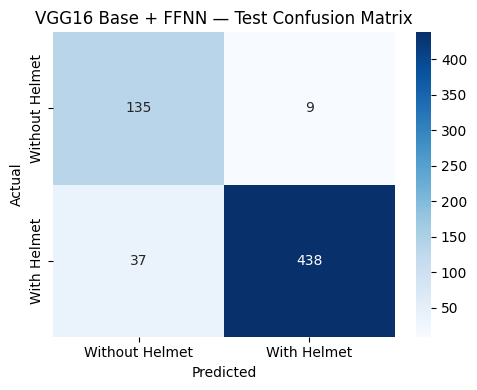

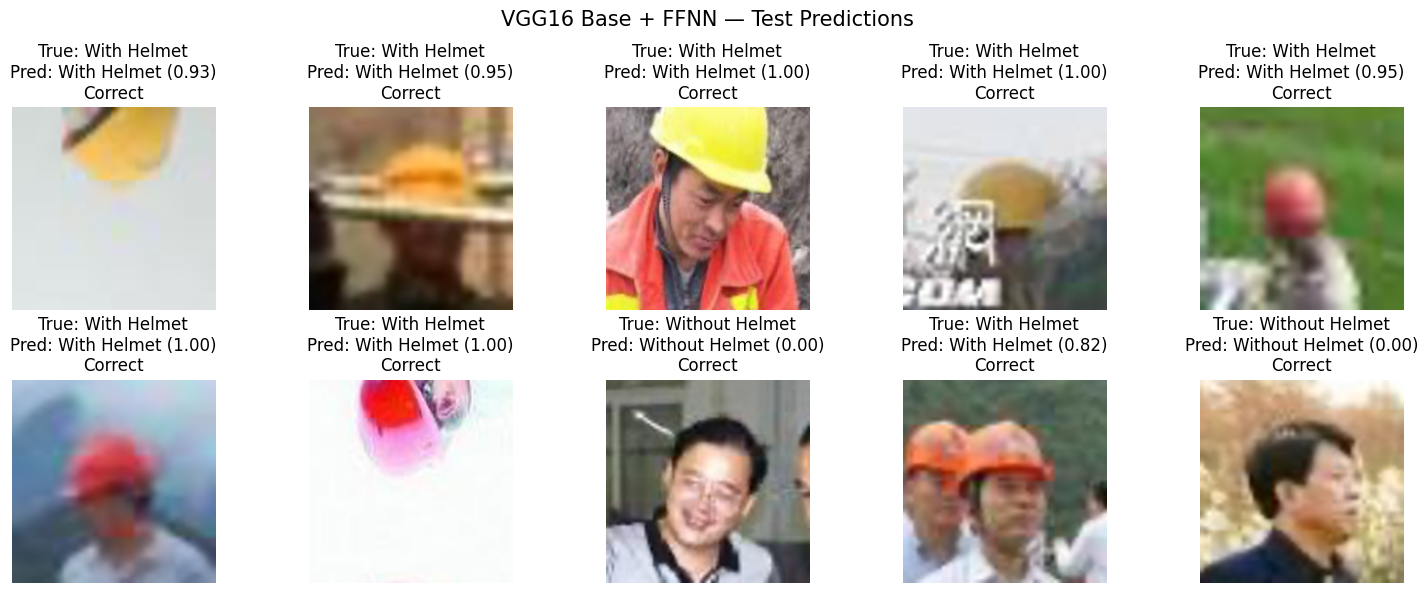

Final test metrics:


,Model,Accuracy,Precision,Recall (Macro),Violation Recall,F1 Score
0,VGG16 Base + FFNN — Test,0.9257,0.9799,0.9298,0.9375,0.9023


Saved final model to: artifacts/helmnet_final_model.keras
Saved comparison table to: artifacts/helmnet_model_comparison.csv


In [ ]:
test_result = evaluate_model(best_model, X_test, y_test, f'{BEST_MODEL_NAME} — Test')
show_predictions(best_model, X_test, y_test, f'{BEST_MODEL_NAME} — Test Predictions')

print('Final test metrics:')
display(pd.DataFrame([test_result]).style.format({
    'Accuracy':'{:.4f}', 'Precision':'{:.4f}', 'Recall (Macro)':'{:.4f}', 'Violation Recall':'{:.4f}', 'F1 Score':'{:.4f}'
}))

# Save the selected model and comparison table to the local artifacts folder.
FINAL_MODEL_PATH = ARTIFACT_DIR / 'helmnet_final_model.keras'
RESULTS_PATH = ARTIFACT_DIR / 'helmnet_model_comparison.csv'
best_model.save(FINAL_MODEL_PATH)
comparison_df.to_csv(RESULTS_PATH)
print('Saved final model to:', FINAL_MODEL_PATH)
print('Saved comparison table to:', RESULTS_PATH)


### **Final Test Performance Comments**
- Similar validation and test metrics indicate good generalization.
- A large drop on the test set indicates overfitting or a distribution mismatch.
- Review false negatives carefully because missed safety violations can have a higher operational cost than false alarms.
- The confusion matrix should be assessed alongside aggregate metrics before deployment.

# **11. Actionable Insights and Recommendations**

1. **Deploy the selected model as an assistive safety-monitoring tool**, not as the sole basis for disciplinary or high-stakes decisions.
2. **Prioritize recall for the “Without Helmet” class** because missing a real violation may expose workers to greater risk. Threshold tuning can be performed on validation data according to business cost.
3. **Use human review for low-confidence predictions**, for example probabilities between 0.40 and 0.60.
4. **Collect more minority-class and difficult images**, especially low-light scenes, occlusions, unusual camera angles, distant workers, and different helmet styles.
5. **Monitor production drift** by tracking confidence, class distribution, false-negative rate, and performance by site/camera.
6. **Retrain periodically** using verified new images and preserve a separate holdout set for unbiased evaluation.
7. **Respect privacy and governance requirements** when processing workplace images; retain only data necessary for the safety objective.
8. **Optimize for deployment** using model quantization or TensorFlow Lite after confirming that the accuracy and recall remain acceptable.

# **12. Conclusion**

This project established a reproducible image-classification workflow and compared a CNN trained from scratch with three VGG16 transfer-learning strategies. Validation F1-score was used for unbiased model selection, and the selected model was evaluated once on the untouched test set. Transfer learning is expected to provide strong performance with limited training data, while augmentation can improve robustness to real-world variation. The final solution should be deployed with confidence thresholds, human oversight, drift monitoring, and continuous data-quality improvement.

# **13. Export the Executed Notebook to HTML in Google Colab**
Run every cell first so that plots, tables, and observations appear in the exported file. Then use the export cell below.

In [ ]:
# Optional HTML export after the notebook has been fully executed.
# In Colab, save/download the notebook first, then update NOTEBOOK_PATH if needed.

NOTEBOOK_PATH = "HelmNet_Helmet_Detection.ipynb"
HTML_OUTPUT_DIR = "."

!jupyter nbconvert --to html "$NOTEBOOK_PATH" --output-dir "$HTML_OUTPUT_DIR"
print("HTML export complete.")
